In [ ]:
import pandas as pd

# Load the Excel dataset
df = pd.read_excel('customer_support_tickets (4).xlsx')

# Check the schema and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

In [ ]:
# Check distribution of Ticket Type
print("--- Ticket Type Distribution ---")
print(df['Ticket Type'].value_counts())

# Check distribution of Ticket Priority
print("\n--- Ticket Priority Distribution ---")
print(df['Ticket Priority'].value_counts())

# Check distribution of Product Purchased (Category)
print("\n--- Product/Category Distribution ---")
print(df['Product Purchased'].value_counts())

--- Ticket Type Distribution ---
Ticket Type
Technical issue         1472
Refund request          1460
Cancellation request    1444
Product inquiry         1365
Billing inquiry         1363
Name: count, dtype: int64

--- Ticket Priority Distribution ---
Ticket Priority
Medium      1839
Critical    1777
Low         1753
High        1735
Name: count, dtype: int64

--- Product/Category Distribution ---
Product Purchased
Canon EOS                         200
Nest Thermostat                   197
Amazon Echo                       193
GoPro Hero                        190
Philips Hue Lights                187
Nintendo Switch Pro Controller    182
LG Smart TV                       181
Sony Xperia                       179
LG OLED                           178
Roomba Robot Vacuum               178
LG Washing Machine                176
Apple AirPods                     175
Sony 4K HDR TV                    175
Garmin Forerunner                 174
iPhone                            173
Microsoft

In [ ]:
# Drop 'Customer Email','Resolution','unamed:9' and customer satisfication rating columns
df.drop(columns=['Customer Email', 'Resolution','Unnamed: 9'], inplace=True, errors='ignore')

# Verify the columns are removed
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Age', 'Customer Gender',
       'Product Purchased', 'Date of Purchase', 'Ticket Type',
       'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [ ]:
# Check the status of the tickets
print(df['Ticket Status'].value_counts())


Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


In [ ]:
# Define the mapping for priority scores
priority_map = {
    'Critical': 4,
    'High': 3,
    'Medium': 2,
    'Low': 1
}

# Create the new Priority_Score column
df['Priority_Score'] = df['Ticket Priority'].map(priority_map)

# View the first few rows to confirm the new column
print(df[['Ticket Priority', 'Priority_Score']].head())


  Ticket Priority  Priority_Score
0        Critical               4
1        Critical               4
2             Low               1
3             Low               1
4             Low               1


In [ ]:
# Check counts for each Priority_Score
print("--- Priority Score Counts ---")
print(df['Priority_Score'].value_counts().sort_index())


--- Priority Score Counts ---
Priority_Score
1    2063
2    2192
3    2085
4    2129
Name: count, dtype: int64


In [ ]:
# Get the frequency count for every Ticket Subject
subject_counts = df['Ticket Subject'].value_counts()

print("--- Ticket Subject Counts ---")
print(subject_counts)

print(f"\nTotal unique subjects: {df['Ticket Subject'].nunique()}")


--- Ticket Subject Counts ---
Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

Total unique subjects: 16


In [ ]:
#to caluculate resolution duration.
df['Resolution_Duration'] = df['Time to Resolution'] - df['First Response Time']

# Convert the duration to days to float for easier analysis
# Tickets not yet closed will result in NaN
df['Resolution_Duration_Days'] = df['Resolution_Duration'].dt.total_seconds() / (24 * 3600)

# Check the new columns for the first few 'Closed' tickets
print("--- Resolution Duration Samples (Days) ---")
print(df[df['Ticket Status'] == 'Closed'][['First Response Time', 'Time to Resolution', 'Resolution_Duration_Days']].head())

--- Resolution Duration Samples (Days) ---
   First Response Time  Time to Resolution  Resolution_Duration_Days
2  2023-06-01 11:14:38 2023-06-01 18:05:38                  0.285417
3  2023-06-01 07:29:40 2023-06-01 01:57:40                 -0.230556
4  2023-06-01 00:12:42 2023-06-01 19:53:42                  0.820139
10 2023-06-01 17:46:49 2023-05-31 23:51:49                 -0.746528
11 2023-06-01 12:05:51 2023-06-01 09:27:51                 -0.109722


In [ ]:

negative_tickets = df[df['Resolution_Duration_Days'] < 0]
print(f"Number of tickets with negative duration: {len(negative_tickets)}")

if len(negative_tickets) > 0:
    print("\n--- Examples of Data Errors (Negative Duration) ---")
    print(negative_tickets[['First Response Time', 'Time to Resolution', 'Resolution_Duration_Days']].head())

df = df[(df['Resolution_Duration_Days'] >= 0) | (df['Resolution_Duration_Days'].isna())]


print("\n--- Cleaned Dataset Info ---")
print(f"Remaining rows: {len(df)}")
print(f"Negative values remaining: {(df['Resolution_Duration_Days'] < 0).sum()}")

Number of tickets with negative duration: 1365

--- Examples of Data Errors (Negative Duration) ---
   First Response Time  Time to Resolution  Resolution_Duration_Days
3  2023-06-01 07:29:40 2023-06-01 01:57:40                 -0.230556
10 2023-06-01 17:46:49 2023-05-31 23:51:49                 -0.746528
11 2023-06-01 12:05:51 2023-06-01 09:27:51                 -0.109722
14 2023-06-01 06:22:55 2023-05-31 23:08:55                 -0.301389
16 2023-06-01 19:46:59 2023-06-01 15:58:59                 -0.158333

--- Cleaned Dataset Info ---
Remaining rows: 7104
Negative values remaining: 0


In [ ]:
# Function to convert the duration into a readable string
def format_duration(td):
    if pd.isna(td):
        return "Pending"
    days = td.days
    hours, remainder = divmod(td.seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{days} days {hours:02}h:{minutes:02}m"

# Apply the formatting
df['Resolution_Duration_Readable'] = df['Resolution_Duration'].apply(format_duration)

# Check the results for Closed tickets
print("--- Readable Resolution Time ---")
print(df[df['Ticket Status'] == 'Closed'][['Resolution_Duration_Days', 'Resolution_Duration_Readable']].head())

--- Readable Resolution Time ---
    Resolution_Duration_Days Resolution_Duration_Readable
2                   0.285417               0 days 06h:51m
4                   0.820139               0 days 19h:41m
19                  0.821528               0 days 19h:43m
28                  0.281944               0 days 06h:46m
29                  0.728472               0 days 17h:29m


In [ ]:
display(df)

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Priority_Score,Resolution_Duration,Resolution_Duration_Days,Resolution_Duration_Readable
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,4,NaT,NaN,Pending
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,4,NaT,NaN,Pending
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,1,0 days 06:51:00,0.285417,0 days 06h:51m
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,1,0 days 19:41:00,0.820139,0 days 19h:41m
5,6,Rebecca Fleming,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,Open,Low,Social media,NaT,NaT,NaN,1,NaT,NaN,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8462,8463,Shelby Douglas,49,Female,Samsung Soundbar,2020-10-21,Refund request,Display issue,Pending Customer Response,Critical,Email,2023-06-02 00:36:18,NaT,NaN,4,NaT,NaN,Pending
8463,8464,Brandon Walsh,54,Other,LG Washing Machine,2021-08-29,Billing inquiry,Data loss,Open,Medium,Email,NaT,NaT,NaN,2,NaT,NaN,Pending
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,NaN,1,NaT,NaN,Pending
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,NaN,4,NaT,NaN,Pending


In [ ]:
import pandas as pd

# Create the minutes column in one line
df['Resolution_Duration_Minutes'] = (pd.to_datetime(df['Time to Resolution']) - pd.to_datetime(df['First Response Time'])).dt.total_seconds() / 60

# View the result
print(df[['Ticket ID', 'Resolution_Duration_Minutes']].head())

   Ticket ID  Resolution_Duration_Minutes
0          1                          NaN
1          2                          NaN
2          3                        411.0
4          5                       1181.0
5          6                          NaN


In [ ]:
display(df)


,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Priority_Score,Resolution_Duration,Resolution_Duration_Days,Resolution_Duration_Readable,Resolution_Duration_Minutes
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,4,NaT,NaN,Pending,NaN
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,4,NaT,NaN,Pending,NaN
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,1,0 days 06:51:00,0.285417,0 days 06h:51m,411.0
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,1,0 days 19:41:00,0.820139,0 days 19h:41m,1181.0
5,6,Rebecca Fleming,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,Open,Low,Social media,NaT,NaT,NaN,1,NaT,NaN,Pending,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8462,8463,Shelby Douglas,49,Female,Samsung Soundbar,2020-10-21,Refund request,Display issue,Pending Customer Response,Critical,Email,2023-06-02 00:36:18,NaT,NaN,4,NaT,NaN,Pending,NaN
8463,8464,Brandon Walsh,54,Other,LG Washing Machine,2021-08-29,Billing inquiry,Data loss,Open,Medium,Email,NaT,NaT,NaN,2,NaT,NaN,Pending,NaN
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,NaN,1,NaT,NaN,Pending,NaN
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,NaN,4,NaT,NaN,Pending,NaN


/tmp/ipython-input-181/564779824.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


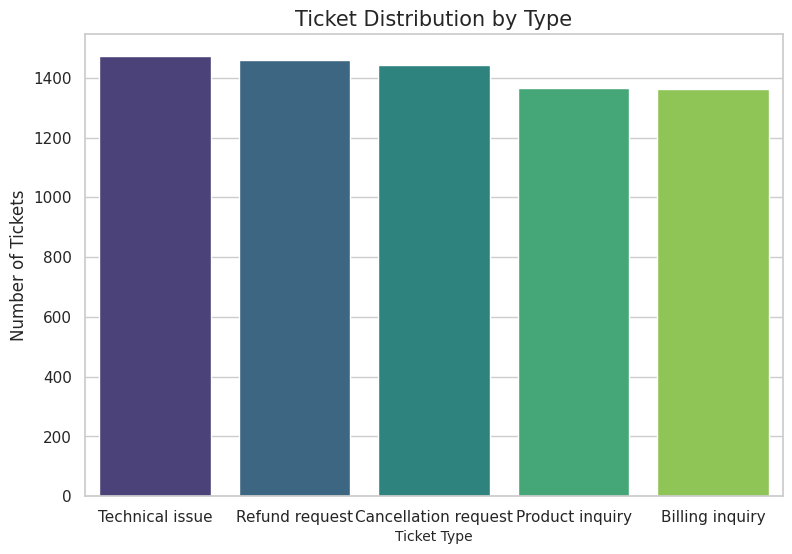

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1.Ticket Type Distribution
plt.figure(figsize=(9, 6))
sns.countplot(
    data=df,
    x='Ticket Type',
    palette='viridis',
    order=df['Ticket Type'].value_counts().index
)

plt.title('Ticket Distribution by Type', fontsize=15)
plt.xlabel('Ticket Type', fontsize=10)
plt.ylabel('Number of Tickets', fontsize=12)


plt.show()

/tmp/ipython-input-181/2068223337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


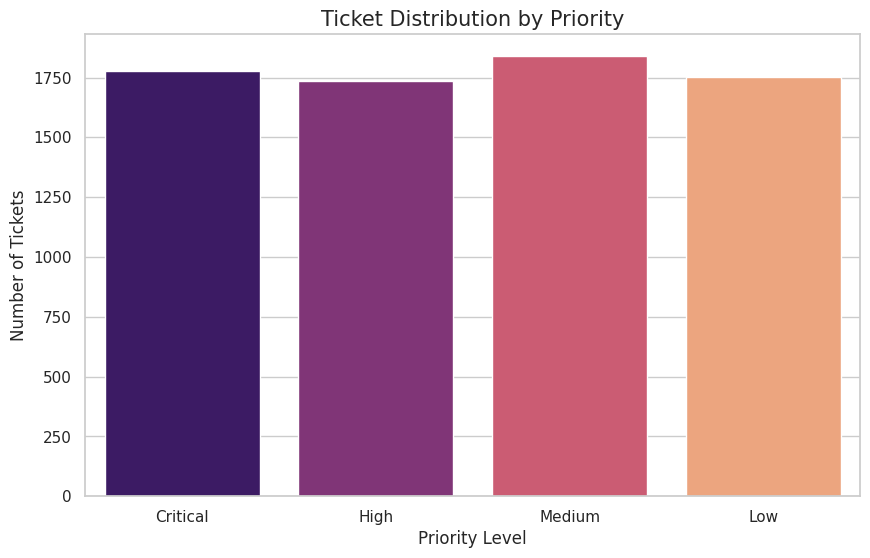

In [ ]:
# 2.Ticket Priority Distribution
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Ticket Priority',
    palette='magma',
    order=['Critical', 'High', 'Medium', 'Low']
)

plt.title('Ticket Distribution by Priority', fontsize=15)
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)

plt.show()


/tmp/ipython-input-181/768457152.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


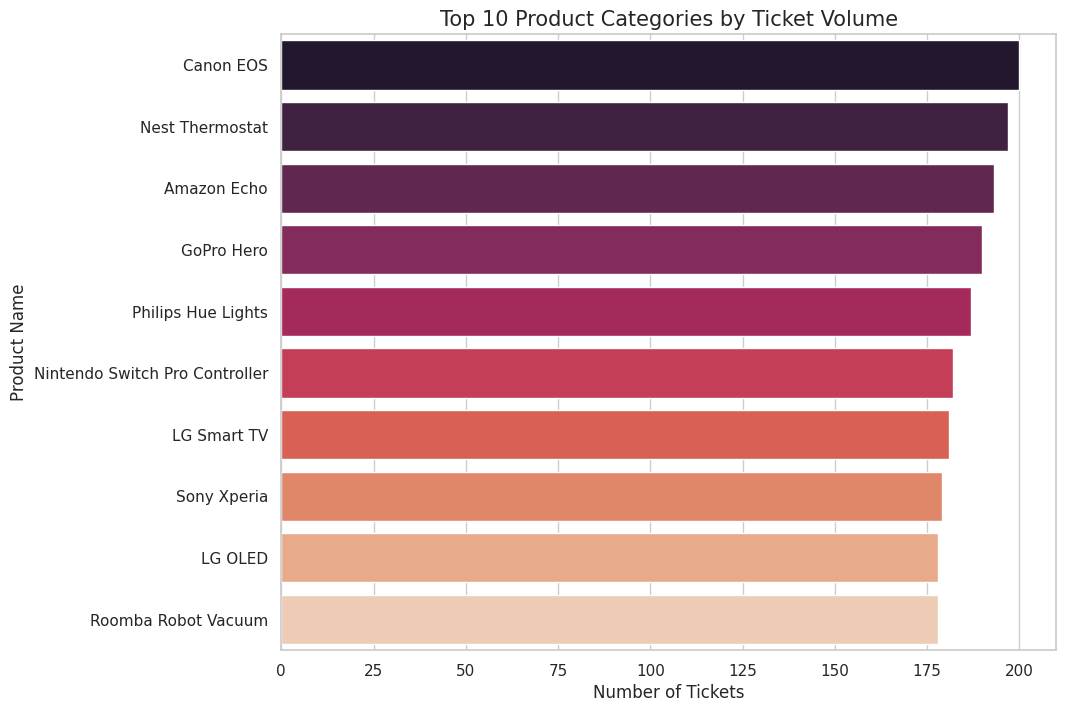

In [ ]:
# 3.Top 10 Products by Ticket Volume
plt.figure(figsize=(10, 8))

top_10_products = df['Product Purchased'].value_counts().nlargest(10).index

sns.countplot(
    data=df[df['Product Purchased'].isin(top_10_products)],
    y='Product Purchased',
    palette='rocket',
    order=top_10_products
)

plt.title('Top 10 Product Categories by Ticket Volume', fontsize=15)
plt.xlabel('Number of Tickets', fontsize=12)
plt.ylabel('Product Name', fontsize=12)


plt.show()


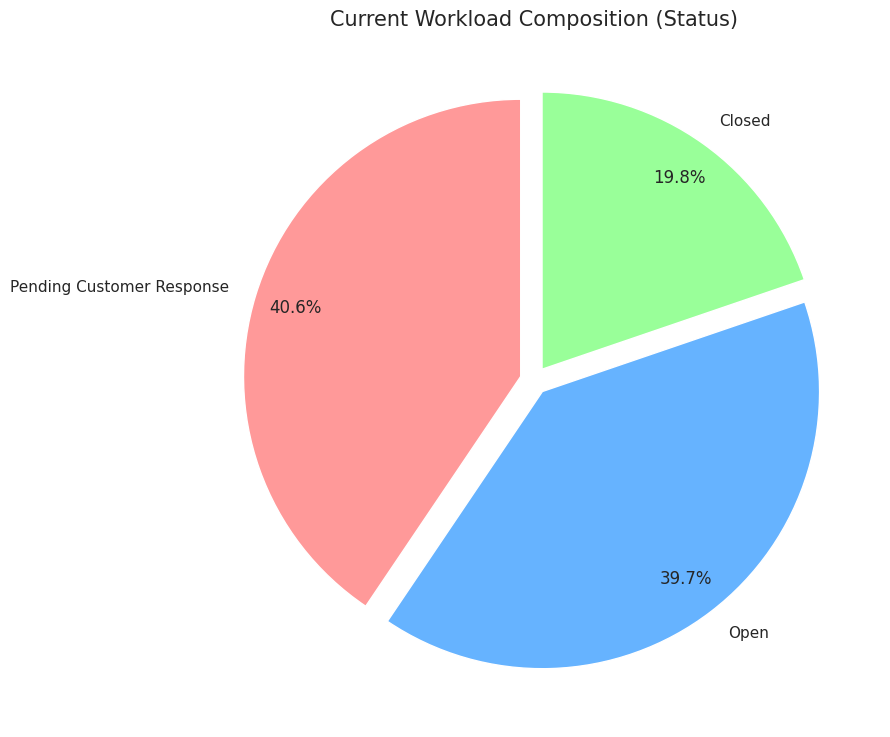

In [ ]:
# 4. Three-way Status Pie Chart
plt.figure(figsize=(9, 9))

status_counts = df['Ticket Status'].value_counts()

colors = ['#ff9999','#66b3ff','#99ff99']

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    explode=(0.05, 0.05, 0.05)
)


plt.title('Current Workload Composition (Status)', fontsize=15)
plt.show()

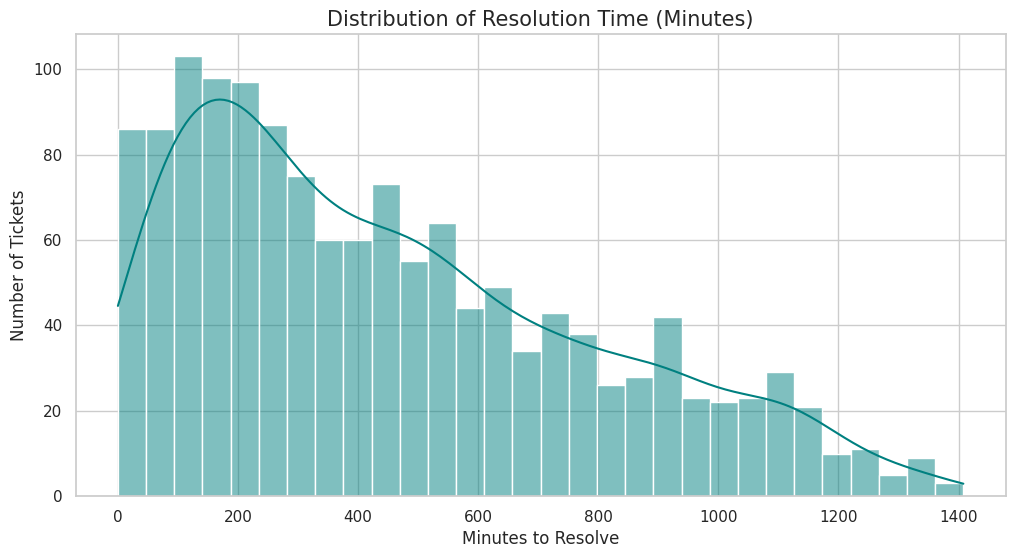

In [ ]:
# 5. Resolution Time Distribution
plt.figure(figsize=(12, 6))

# Calculate Resolution_Duration_Minutes for the main df
df['Resolution_Duration_Minutes'] = df['Resolution_Duration'].dt.total_seconds() / 60

closed_tickets = df[df['Ticket Status'] == 'Closed']

sns.histplot(closed_tickets['Resolution_Duration_Minutes'], bins=30, kde=True, color='teal')


plt.title('Distribution of Resolution Time (Minutes)', fontsize=15)
plt.xlabel('Minutes to Resolve', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)

plt.show()

In [ ]:
# frequency count for every Product
product_counts = df['Product Purchased'].value_counts()


print("--- Product Ticket Counts ---")
print(product_counts)

print(f"\nTotal unique products: {df['Product Purchased'].nunique()}")

--- Product Ticket Counts ---
Product Purchased
Canon EOS                         200
Nest Thermostat                   197
Amazon Echo                       193
GoPro Hero                        190
Philips Hue Lights                187
Nintendo Switch Pro Controller    182
LG Smart TV                       181
Sony Xperia                       179
LG OLED                           178
Roomba Robot Vacuum               178
LG Washing Machine                176
Apple AirPods                     175
Sony 4K HDR TV                    175
Garmin Forerunner                 174
iPhone                            173
Microsoft Xbox Controller         172
Samsung Galaxy                    172
HP Pavilion                       172
Dyson Vacuum Cleaner              170
Google Nest                       169
Sony PlayStation                  168
Google Pixel                      168
Fitbit Charge                     167
Nikon D                           166
Amazon Kindle                     166
Mi

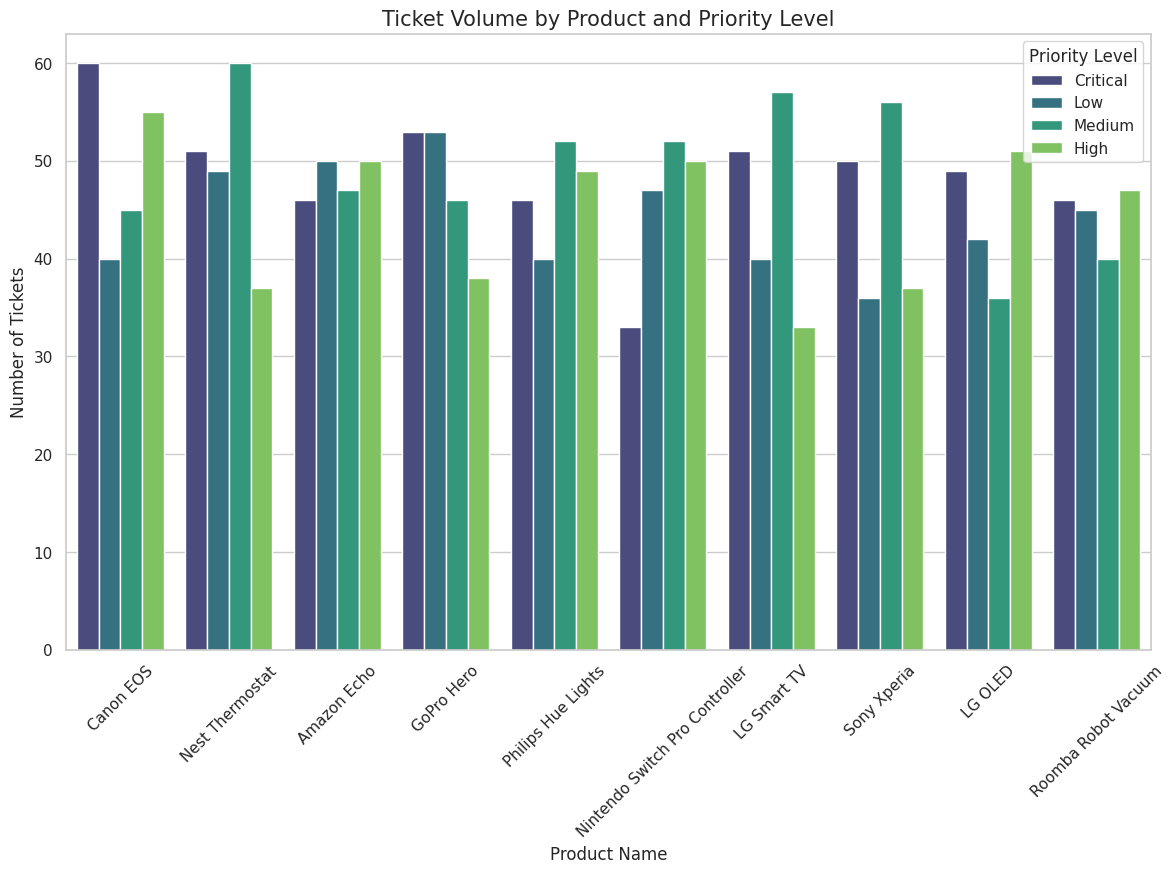

In [ ]:
# 6.Product vs. Priority (grouped bar chart)
plt.figure(figsize=(14, 8))

top_products = df['Product Purchased'].value_counts().nlargest(10).index
df_top_products = df[df['Product Purchased'].isin(top_products)]

sns.countplot(
    data=df_top_products,
    x='Product Purchased',
    hue='Ticket Priority',
    palette='viridis',
    order=top_products
)

plt.title('Ticket Volume by Product and Priority Level', fontsize=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.legend(title='Priority Level')

plt.xticks(rotation=45)

plt.show()

/tmp/ipython-input-181/3130617421.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Issue_Cluster', palette='coolwarm', order=order)


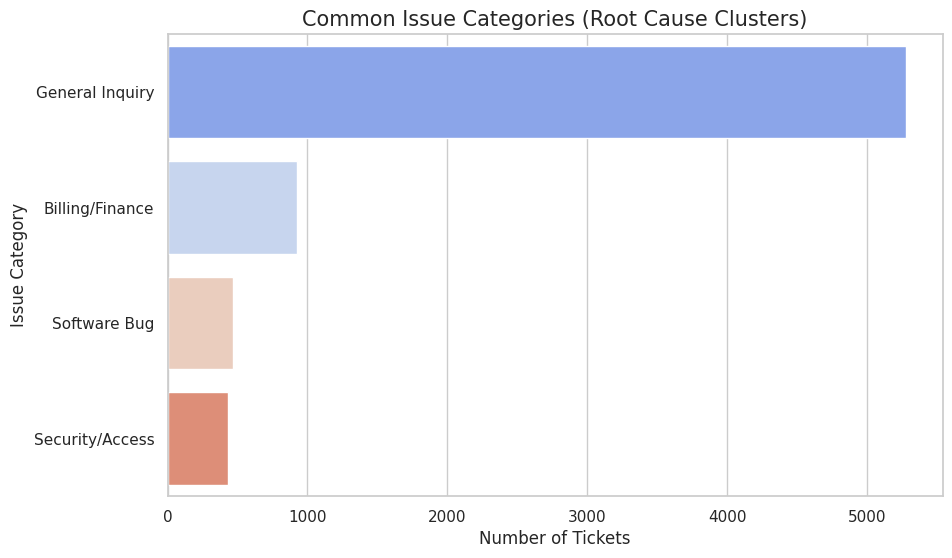

In [ ]:
# a  clustering function
def categorize_issue(subject):
    subject = str(subject).lower()
    if any(word in subject for word in ['bug', 'error', 'crash', 'fail', 'broken']):
        return 'Software Bug'
    if any(word in subject for word in ['security', 'password', 'login', 'access', 'hack', 'auth']):
        return 'Security/Access'
    if any(word in subject for word in ['api', 'connect', 'integration', 'sync', 'bridge']):
        return 'Integration'
    if any(word in subject for word in ['billing', 'refund', 'payment', 'price', 'invoice']):
        return 'Billing/Finance'
    return 'General Inquiry'

df['Issue_Cluster'] = df['Ticket Subject'].apply(categorize_issue)


plt.figure(figsize=(10, 6))
order = df['Issue_Cluster'].value_counts().index
sns.countplot(data=df, y='Issue_Cluster', palette='coolwarm', order=order)

plt.title('Common Issue Categories (Root Cause Clusters)', fontsize=15)
plt.xlabel('Number of Tickets', fontsize=12)
plt.ylabel('Issue Category', fontsize=12)
plt.show()

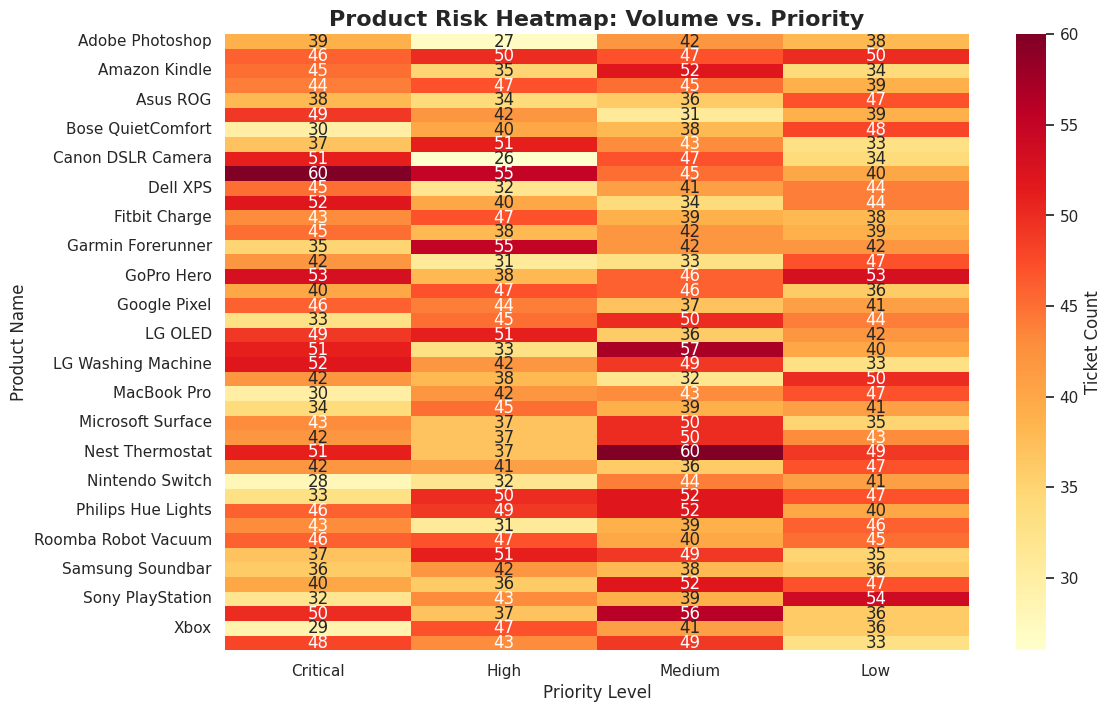

In [ ]:
# Create a Cross-tabulation of Product and Priority
pivot_table = pd.crosstab(df['Product Purchased'], df['Ticket Priority'])

cols = [c for c in ['Critical', 'High', 'Medium', 'Low'] if c in pivot_table.columns]
pivot_table = pivot_table[cols]

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Ticket Count'})

plt.title('Product Risk Heatmap: Volume vs. Priority', fontsize=16, fontweight='bold')
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.show()

Issue_Cluster
General Inquiry    5276
Billing/Finance     927
Software Bug        469
Security/Access     432
Name: count, dtype: int64


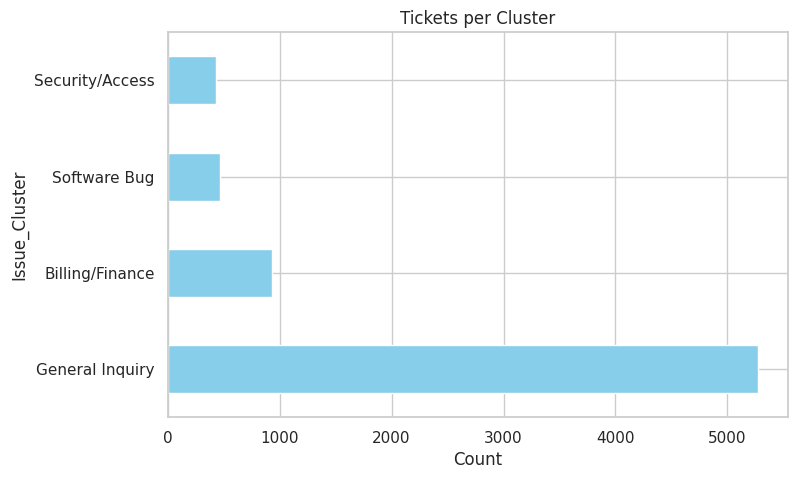

In [ ]:

counts = df['Issue_Cluster'].value_counts()
print(counts)

plt.figure(figsize=(8, 5))
counts.plot(kind='barh', color='skyblue')

plt.title('Tickets per Cluster')
plt.xlabel('Count')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Create a list to store our findings
sim_results = []

# We check each cluster one by one
for cluster in df['Issue_Cluster'].unique():
    # Get the subjects for this specific cluster
    subjects = df[df['Issue_Cluster'] == cluster]['Ticket Subject']

    if len(subjects) > 1:
        # Turn text into numbers so the computer can 'read' them
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform(subjects)

        # Compare every ticket to every other ticket in the group
        matrix = cosine_similarity(tfidf_matrix)

        # Find the average score (ignoring the 1.0s where a ticket matches itself)
        avg = (np.sum(matrix) - len(subjects)) / (len(subjects)**2 - len(subjects))
        sim_results.append({'Cluster': cluster, 'Score': avg})

# Display the results in a simple table
similarity_df = pd.DataFrame(sim_results).sort_values(by='Score', ascending=False)
print(similarity_df)

           Cluster     Score
3  Security/Access  1.000000
2     Software Bug  1.000000
1  Billing/Finance  0.500346
0  General Inquiry  0.116407


In [ ]:
import pandas as pd
from google.colab import files

# Save the current DataFrame to an Excel file
df.to_excel('current_data.xlsx', index=False)

# Download the Excel file
files.download('current_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import random

df = pd.read_excel('current_data.xlsx') # Changed to read_excel

# 2. Define countries and their coordinates
geo_data = {
    'USA': [37.09, -95.71],
    'UK': [55.37, -3.43],
    'India': [20.59, 78.96],
    'Canada': [56.13, -106.34],
    'Australia': [-25.27, 133.77]
}

# 3. Randomly assign a country to each ticket
countries_list = list(geo_data.keys())
df['Country'] = [random.choice(countries_list) for _ in range(len(df))]

# 4. Map the Latitude and Longitude
df['Latitude'] = df['Country'].apply(lambda x: geo_data[x][0])
df['Longitude'] = df['Country'].apply(lambda x: geo_data[x][1])

df.to_excel('final_data.xlsx', index=False)
print("Success! You now have Country, Lat, and Long columns.")

Success! You now have Country, Lat, and Long columns.
